# AI-Powered Fake News Detection using NLP and Machine Learning

### Developed using Natural Language Processing (NLP) and Machine Learning techniques to classify news articles as Real or Fake.


## Author

Vemalatha Bhimireddy


This project demonstrates the application of Natural Language Processing (NLP) and Machine Learning techniques for detecting fake news articles.

The system preprocesses textual news data, converts it into numerical features using TF-IDF vectorization, and applies Logistic Regression to classify news articles as real or fake.

The project also includes model evaluation, cross-validation, inference pipeline creation, and model export for future deployment as a web application.


## Problem Statement

Fake news and misinformation have become major challenges in the digital era. The rapid spread of misleading information through online platforms can negatively influence public opinion and decision-making.

The objective of this project is to develop a Machine Learning-based fake news detection system capable of classifying news articles as real or fake using Natural Language Processing techniques.


### Dataset Source

Dataset used:
Fake and Real News Dataset from Kaggle.

## Objectives

* Perform text preprocessing on news articles
* Convert textual data into numerical features using TF-IDF
* Train a Machine Learning model for fake news detection
* Evaluate model performance using multiple metrics
* Build an inference pipeline for real-world prediction


## Import Required Libraries

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

## 1. Dataset Loading

## Dataset Description

The dataset consists of news articles categorized as real or fake news.

* Fake news articles were labeled as 0
* Real news articles were labeled as 1

Both datasets were combined into a single dataframe for model training and evaluation.


In [89]:
fake = pd.read_csv("/content/Fake.csv.zip")
true = pd.read_csv("/content/True.csv.zip")

#2.Initial Dataset Inspection
The dataset is inspected to understand:

number of rows and columns,
feature datatypes,
missing values,
and overall dataset structure before preprocessing.

In [90]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [91]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [92]:
print("Fake News Dataset Shape:", fake.shape)
print("Real News Dataset Shape:", true.shape)

Fake News Dataset Shape: (23481, 4)
Real News Dataset Shape: (21417, 4)


In [93]:
fake.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [94]:
true.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [95]:
fake.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [96]:
true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [97]:
fake.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [98]:
true.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [99]:
fake["label"] = 0
true["label"] = 1

### Dataset Merging

In [100]:
data = pd.concat([fake, true], axis=0)

In [101]:
print("Dataset Shape:", data.shape)

Dataset Shape: (44898, 5)


In [102]:
data.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


### Class Distribution Analysis

In [103]:
data["label"].value_counts()

,count
label,
0,23481
1,21417


### Class Distribution Visualization

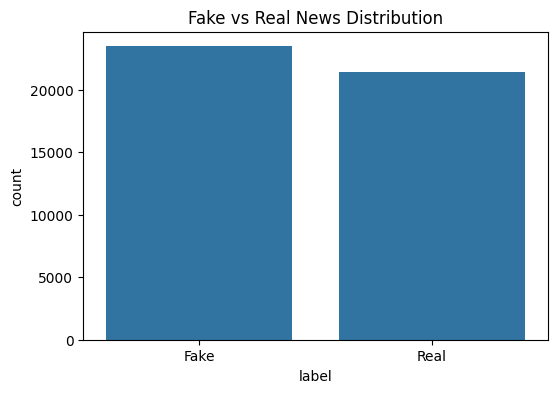

In [104]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=data)
plt.xticks([0,1], ['Fake', 'Real'])
plt.title("Fake vs Real News Distribution")
plt.show()

### Dataset Shuffling

In [105]:
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

### Dataset Observations

* The dataset contains both real and fake news articles.
* No major missing values were identified.
* The class distribution appears balanced, which helps reduce model bias during training.
* The dataset was shuffled randomly before training to improve generalization.


## 3. Text Preprocessing

The raw textual data cannot be directly fed into machine learning algorithms, as they require numerical inputs. This section establishes a pipeline to clean, tokenize, and standardize the text data to minimize noise and improve model consistency.

### Raw Text Sample
To analyze the initial state of the text, identifying noise like URLs, HTML tags, or specific punctuation patterns.

In [106]:
raw_sample = data["text"][0]
print("--- Raw Text Sample ---")
print(raw_sample)

--- Raw Text Sample ---
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Order.READ MORE TRUMP NEWS AT: 21st Century Wire Trump FilesSUPPORT OU

In [107]:
# Download vocabulary and linguistic lexicons
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Initialize functional tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("NLP Environment and dependencies initialized successfully.")

NLP Environment and dependencies initialized successfully.


In [108]:
# Text cleaning function

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove common news source names to reduce dataset bias
    leakage_terms = ["reuters", "bbc", "ap ", "associated press", "washington post", "nytimes"]

    for term in leakage_terms:
        text = text.replace(term, "")

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Split text into words
    words = text.split()

    # Remove stopwords and apply lemmatization
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Remove very short words
    cleaned_words = [word for word in cleaned_words if len(word) > 2]

    # Join cleaned words back into a sentence
    return " ".join(cleaned_words)


# Apply cleaning function to the dataset
data["clean_text"] = data["text"].apply(clean_text)

print("Text preprocessing completed successfully.")

Text preprocessing completed successfully.


## Preprocessing Validation

To verify that the cleaning pipeline worked correctly, we compare the original text with the cleaned text. This helps confirm that unnecessary noise was removed while preserving meaningful information.

In [109]:
data[["text", "clean_text"]].head()

,text,clean_text
0,"21st Century Wire says Ben Stein, reputable pr...",century wire say ben stein reputable professor...
1,WASHINGTON (Reuters) - U.S. President Donald T...,washington president donald trump removed chie...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,puerto rico governor ricardo rossello said wed...
3,"On Monday, Donald Trump once again embarrassed...",monday donald trump embarrassed country accide...
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",glasgow scotland presidential candidate abroad...


### Preprocessing Observations

The preprocessing pipeline successfully cleaned and normalized the textual data by removing noise, punctuation, stopwords, and unnecessary characters.

These preprocessing steps improve text quality and help the machine learning model learn more meaningful textual patterns.


## 4. Data Splitting and Feature Extraction

Machine learning models require numerical input rather than raw text. In this section, the dataset is first divided into training and testing subsets to ensure proper evaluation without data leakage.

The cleaned text is then converted into numerical feature vectors using TF-IDF (Term Frequency–Inverse Document Frequency) vectorization. This approach assigns importance scores to words based on their frequency within individual documents and across the dataset.


### TF-IDF Vectorization

TF-IDF Vectorization was used to convert textual news content into numerical feature vectors.

TF-IDF assigns higher importance to informative words while reducing the influence of commonly occurring but less meaningful words.


In [110]:
X = data["clean_text"]
y = data["label"]

# Train-test split BEFORE vectorization
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.7
)

# Fit only on training data, explicitly passing values to ensure correct array type
X_train = vectorizer.fit_transform(X_train_text.values)

# Transform test data, explicitly passing values to ensure correct array type
X_test = vectorizer.transform(X_test_text.values)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (35918, 5000)
Testing shape: (8980, 5000)


In [111]:
feature_names = vectorizer.get_feature_names_out()

print("--- Sample TF-IDF Vocabulary Terms ---")
print(feature_names[:20])

--- Sample TF-IDF Vocabulary Terms ---
['abadi' 'abandon' 'abandoned' 'abc' 'abc news' 'abe' 'abedin' 'ability'
 'able' 'abortion' 'abroad' 'absolute' 'absolutely' 'absurd' 'abu' 'abuse'
 'academic' 'accept' 'acceptable' 'accepted']


### Feature Extraction Observations

The TF-IDF vectorizer successfully transformed textual news data into high-dimensional numerical feature vectors suitable for machine learning model training.


## 5. Model Selection and Training (Logistic Regression)

After converting the text data into TF-IDF feature vectors, we train a Logistic Regression classifier for binary fake news classification.

Logistic Regression is highly effective for high-dimensional sparse text data and is widely used in NLP classification tasks due to its efficiency, interpretability, and strong baseline performance.



In [112]:
model = LogisticRegression(max_iter=1000,random_state=42)

model.fit(X_train, y_train)

print("Classifier training complete. Model weights have converged successfully.")

Classifier training complete. Model weights have converged successfully.


### Model Training Observations

Logistic Regression was selected for classification because it performs effectively on sparse high-dimensional textual data generated through TF-IDF vectorization.

The model trained successfully and learned meaningful patterns from the news articles.


## 6. Model Evaluation

To evaluate model performance, predictions are generated on the unseen test dataset (`X_test`). Multiple evaluation metrics are used to measure classification quality, generalization performance, and overfitting behavior.

### Classification Report

In [113]:
y_pred = model.predict(X_test)
# Calculate the absolute mathematical accuracy metric
accuracy = accuracy_score(y_test, y_pred)

print("--- Model Evaluation Results---")
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Performance Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake News (0)", "Real News (1)"]
))

--- Model Evaluation Results---
Overall Model Accuracy: 98.17%

Detailed Performance Report:
               precision    recall  f1-score   support

Fake News (0)       0.99      0.98      0.98      4696
Real News (1)       0.98      0.99      0.98      4284

     accuracy                           0.98      8980
    macro avg       0.98      0.98      0.98      8980
 weighted avg       0.98      0.98      0.98      8980



### Train-Test Performance Comparison

In [114]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9856617851773484
Testing Accuracy: 0.9817371937639198


Confusion Matrix

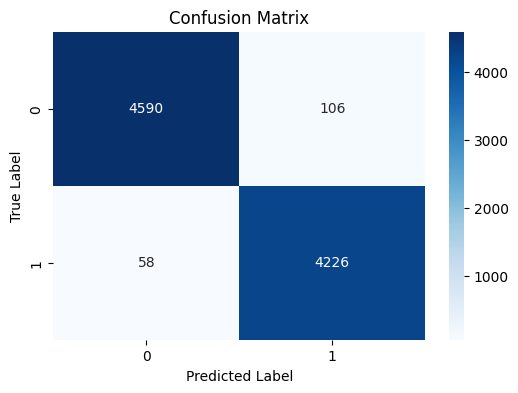

In [115]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix indicates that the model correctly classified most real and fake news samples, demonstrating strong classification capability with relatively few misclassifications.


### ROC-AUC Analysis

In [116]:
y_prob = model.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.9976930721181148


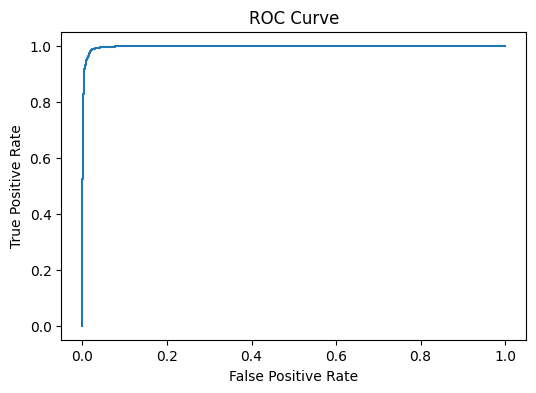

In [117]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

The ROC-AUC score demonstrates that the model effectively distinguishes between real and fake news articles across different classification thresholds.


## 7. Cross Validation

In [118]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.97842428 0.97717149 0.97870267 0.97828205 0.97925658]
Average CV Accuracy: 0.9783674147726303


## 8. Important Words Analysis

The Logistic Regression model assigns coefficients to words based on their contribution toward predicting real or fake news.

Positive coefficients indicate words associated with real news, while negative coefficients indicate words associated with fake news.

Analyzing important words improves interpretability and provides insight into the textual patterns learned by the model.


In [119]:
# Get feature importance from Logistic Regression

feature_importance = pd.DataFrame({
    'Word': vectorizer.get_feature_names_out(),
    'Coefficient': model.coef_[0]
})

# Top fake news indicators
top_fake = feature_importance.sort_values(
    by='Coefficient'
).head(15)

# Top real news indicators
top_real = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
).head(15)

print("Top Words Indicating Fake News")
display(top_fake)

print("\nTop Words Indicating Real News")
display(top_real)

Top Words Indicating Fake News


,Word,Coefficient
4760,via,-12.185158
3518,read,-7.548994
2107,image,-6.859541
3326,president trump,-6.707944
1857,gop,-5.925797
4911,wire,-5.771712
1603,featured image,-5.237000
1602,featured,-5.143924
1474,even,-4.769896
2009,hillary,-4.738969



Top Words Indicating Real News


,Word,Coefficient
4841,washington,8.362205
3317,president donald,7.323610
4865,wednesday,6.921483
4646,tuesday,6.466702
4489,thursday,6.073205
1769,friday,5.549948
2788,monday,5.480623
3832,said statement,5.010412
2954,nov,4.327607
4172,spokesman,4.310144


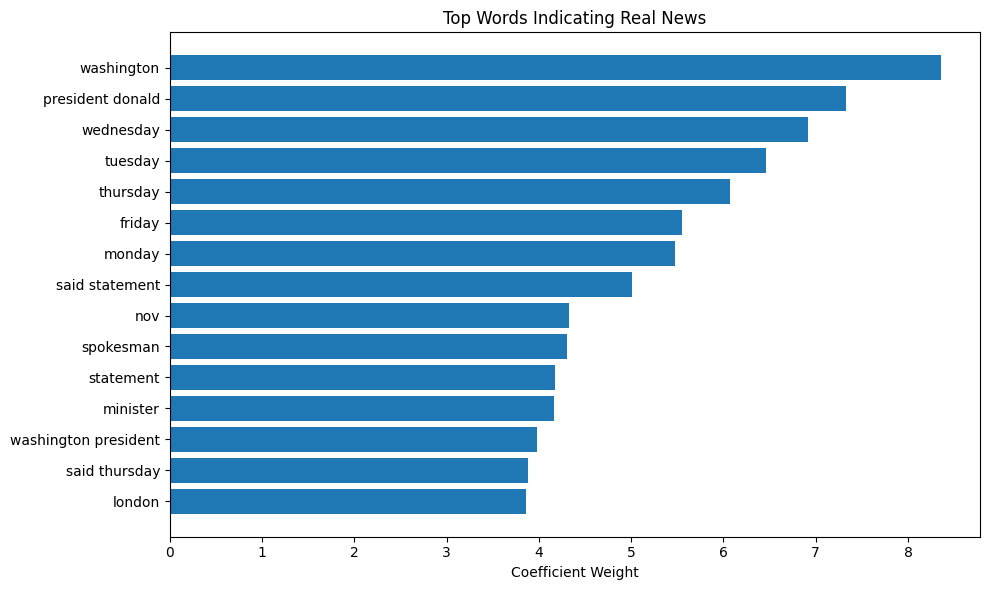

In [120]:
# Visualization for real news indicators

plt.figure(figsize=(10,6))

plt.barh(
    top_real['Word'],
    top_real['Coefficient']
)

plt.xlabel("Coefficient Weight")
plt.title("Top Words Indicating Real News")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

The above visualization highlights words that strongly contribute toward predicting real news articles based on the learned coefficients of the Logistic Regression model.


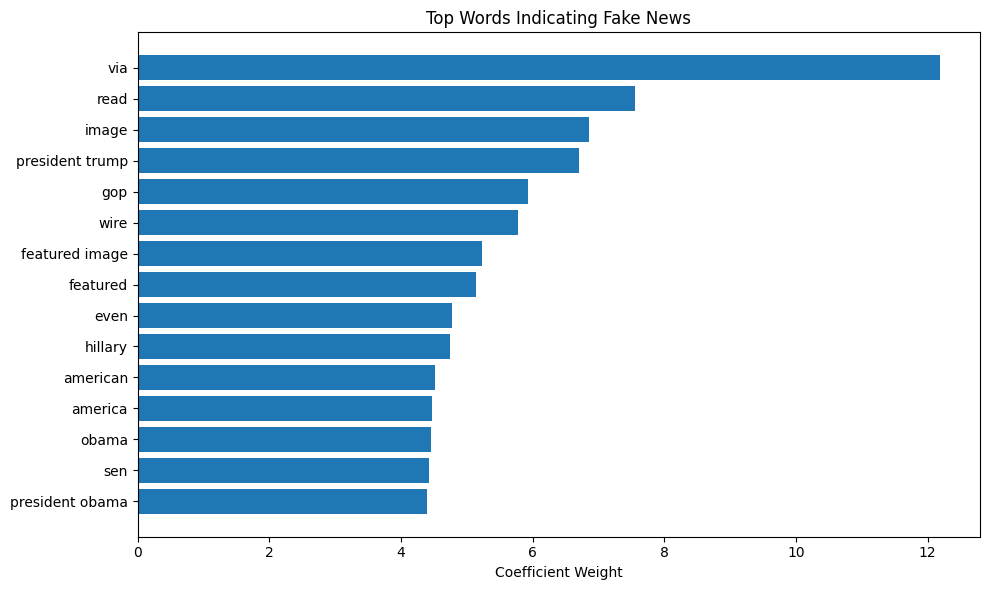

In [121]:
# Visualization for fake news indicators

plt.figure(figsize=(10,6))

plt.barh(
    top_fake['Word'],
    abs(top_fake['Coefficient'])
)

plt.xlabel("Coefficient Weight")
plt.title("Top Words Indicating Fake News")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

The above visualization highlights words that strongly contribute toward predicting fake news articles and represent influential patterns learned from misleading textual content.


## 9. Inference Pipeline

To make the trained model usable on new text inputs, we build a prediction pipeline that:
- preprocesses raw text,
- converts it into TF-IDF features,
- and generates a classification prediction using the trained Logistic Regression model.

In [122]:
# Custom News Prediction Function

def predict_custom_news(text):
    """
    Predicts whether a news article is Fake or Real.

    Parameters:
        text (str): Raw news text input.

    Returns:
        str: Predicted class label.
    """

    # Clean the input text
    cleaned_text = clean_text(text)

    # Convert text into TF-IDF features
    text_vector = vectorizer.transform([cleaned_text])

    # Generate prediction
    prediction = model.predict(text_vector)[0]

    # Return label
    if prediction == 0:
        return "Classification: Fake News"
    else:
        return "Classification: Real News"


print("Inference pipeline initialized successfully.")

Inference pipeline initialized successfully.


In [123]:
#  Testing the Inference Pipeline

# Example 1
sample_real_news = (
    "The central bank increased interest rates by 25 basis points "
    "during the financial policy meeting."
)

# Example 2
sample_fake_news = (
    "Secret underground alien societies are controlling global energy systems."
)

# Run predictions
real_result = predict_custom_news(sample_real_news)
fake_result = predict_custom_news(sample_fake_news)

# Display results
print("=== Inference Pipeline Test ===\n")

print("Input 1:")
print(sample_real_news)
print(real_result)

print("\nInput 2:")
print(sample_fake_news)
print(fake_result)

=== Inference Pipeline Test ===

Input 1:
The central bank increased interest rates by 25 basis points during the financial policy meeting.
Classification: Real News

Input 2:
Secret underground alien societies are controlling global energy systems.
Classification: Fake News


### Inference Pipeline Observations

The inference pipeline enables real-time prediction on custom news articles by applying the same preprocessing and TF-IDF transformation steps used during model training.


## 10. Model Persistence and Export

To reuse the trained machine learning pipeline without retraining, we save both the TF-IDF vectorizer and the trained Logistic Regression model using Python’s `pickle` module.

These exported `.pkl` files can later be loaded into applications such as Flask, FastAPI, or Streamlit for real-time fake news prediction.

In [124]:
# Save the trained vectorizer and model

import pickle

# Save TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)

# Save trained Logistic Regression model
with open("fake_news_classifier.pkl", "wb") as model_file:
    pickle.dump(model, model_file)

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


### Model Export Observations

The trained model and TF-IDF vectorizer were successfully exported using pickle serialization, enabling future deployment and reuse without retraining.


## 11. Prediction Confidence and Custom Testing
To better understand model predictions, we generate probability-based confidence scores for custom news examples. This helps evaluate how confidently the classifier distinguishes between fake and real news samples.

In [125]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Compute explicit scalar values for the classification performance
metric_accuracy  = accuracy_score(y_test, y_pred)
metric_precision = precision_score(y_test, y_pred)
metric_recall    = recall_score(y_test, y_pred)
metric_f1        = f1_score(y_test, y_pred)

print("=== Isolated Performance Metrics ===")
print(f"Calculated Accuracy  : {metric_accuracy:.4f} ({metric_accuracy * 100:.2f}%)")
print(f"Calculated Precision : {metric_precision:.4f} ({metric_precision * 100:.2f}%)")
print(f"Calculated Recall    : {metric_recall:.4f} ({metric_recall * 100:.2f}%)")
print(f"Calculated F1-Score  : {metric_f1:.4f} ({metric_f1 * 100:.2f}%)")
print("====================================")

=== Isolated Performance Metrics ===
Calculated Accuracy  : 0.9817 (98.17%)
Calculated Precision : 0.9755 (97.55%)
Calculated Recall    : 0.9865 (98.65%)
Calculated F1-Score  : 0.9810 (98.10%)


In [126]:
# Check performance on the training data to compare against test data
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("=== Overfitting Diagnostic Check ===")
print(f"Training Data Accuracy : {train_accuracy * 100:.2f}%")
print(f"Testing Data Accuracy  : {metric_accuracy * 100:.2f}%")
print(f"Mathematical Variance  : {abs(train_accuracy - metric_accuracy) * 100:.2f}%")

=== Overfitting Diagnostic Check ===
Training Data Accuracy : 98.57%
Testing Data Accuracy  : 98.17%
Mathematical Variance  : 0.39%


### Prediction Confidence Observations

The prediction confidence scores provide insight into how strongly the model classifies a news article as real or fake.

Higher confidence values indicate stronger certainty in the prediction outcome.


In [127]:
import numpy as np

def predict_news(text):

    cleaned_text = clean_text(text)
    vectorized_text = vectorizer.transform([cleaned_text])

    probabilities = model.predict_proba(vectorized_text)[0]

    pred_index = np.argmax(probabilities)

    label = model.classes_[pred_index]
    confidence = probabilities[pred_index]

    print("Prediction:", "Fake News" if label == 0 else "Real News")
    print("Confidence Score:", round(confidence, 4))

Real News Example

In [128]:
predict_news("""
The Reserve Bank of India announced new monetary policy reforms
to control inflation and stabilize economic growth.
""")

Prediction: Fake News
Confidence Score: 0.5386


Fake News Example

In [129]:
predict_news("""
Scientists confirmed that drinking hot chocolate daily
can increase human lifespan by 50 years instantly.
""")

Prediction: Fake News
Confidence Score: 0.9122


Borderline Claim Example

In [130]:
predict_news("""
A viral social media post claimed that artificial intelligence
will replace all software engineers within the next 2 years.
""")

Prediction: Fake News
Confidence Score: 0.6211


## Conclusion

This project successfully demonstrates the application of Natural Language Processing (NLP) and Machine Learning techniques for fake news detection.

The Logistic Regression model achieved strong classification performance using TF-IDF vectorized textual features. The evaluation metrics, ROC-AUC score, and cross-validation results indicate that the model generalizes well and performs reliably on unseen news articles.

The project also includes a complete inference pipeline and model persistence system, enabling future deployment as an interactive web application.

This system can assist in identifying potentially misleading news content and demonstrates the practical application of AI in media verification and information analysis.


# Final Project Summary

This project demonstrates the successful implementation of a Machine Learning-based fake news detection system using Natural Language Processing techniques.

The workflow included:

* text preprocessing
* TF-IDF feature extraction
* Logistic Regression model training
* model evaluation
* cross-validation
* feature importance analysis
* inference pipeline creation
* model persistence for deployment

The project achieved strong classification performance and is suitable for future deployment as an interactive web application for real-time fake news detection.
